# DRM & Interconnector Flow Features

Pulls two data series and engineers **no-leakage day-ahead features**:

| Series | Source endpoint | Feature shift |
|---|---|---|
| De-rated Margin / LoLP | `forecast/system/loss-of-load` | D-2 → D |
| Interconnector actual flows | `generation/outturn/interconnectors` | D-2 → D |

**Why D-2 shift?**  
Day-ahead bids for day D are submitted before 10:00 on D-1. At that point, only D-2 has a **complete** full-day record of DRM and interconnector actuals. D-1 data is still accumulating (settlement periods close throughout the day) and cannot be treated as fully known. Both series therefore use D-2 aggregates as features for D.

Output: `data/processed/features_drm_interconnectors.parquet`  
Index: `target_date` (the day being forecast, i.e. day D)

In [1]:
import sys
sys.path.insert(0, '.')  # project root

import logging
import time
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

from src.clustering.data_loader import load_lolp_drm
from src.clustering.config import ELEXON_BASE_URL, ELEXON_BATCH_DAYS

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

In [2]:
# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
START_DATE = "2023-01-01"
END_DATE   = "2026-03-01"

RAW_CACHE_DIR  = Path("data/raw")
OUT_PATH       = Path("data/processed/features_drm_interconnectors.parquet")

IC_CACHE_FILE  = RAW_CACHE_DIR / "interconnectors" / f"ic_{START_DATE}_{END_DATE}.parquet"
IC_CACHE_FILE.parent.mkdir(parents=True, exist_ok=True)
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Evening peak settlement periods (16:00–19:00 UTC, i.e. SP 33–38)
EVENING_PEAK_SPS = list(range(33, 39))

## 1. De-rated Margin (DRM)

In [3]:
# Uses existing load_lolp_drm which:
#   - fetches forecast/system/loss-of-load in 7-day batches
#   - takes the mean across all hourly publications for each (date, SP)
#   - caches to data/raw/lolp_drm/
drm_raw = load_lolp_drm(START_DATE, END_DATE)
print(drm_raw.shape)
drm_raw.head()

INFO Loading LoLP/DRM from cache: /Users/haowu/Projects/BESS/data/raw/lolp_drm/lolp_drm_2023-01-01_2026-03-01.parquet


(55488, 4)


,settlement_date,settlement_period,lolp,drm
0,2023-01-01,1,0.0,23163.6812
1,2023-01-01,2,0.0,22900.4048
2,2023-01-01,3,0.0,23310.1576
3,2023-01-01,4,0.0,24402.2508
4,2023-01-01,5,0.0,24091.8772


In [4]:
# Sanity check: SPs per day
sps_per_day = drm_raw.groupby('settlement_date')['settlement_period'].count()
print("SP counts:", sps_per_day.value_counts().to_dict())
print(f"Date range: {drm_raw['settlement_date'].min()} → {drm_raw['settlement_date'].max()}")
print(f"DRM range:  {drm_raw['drm'].min():.0f} – {drm_raw['drm'].max():.0f} MW")

SP counts: {48: 1150, 46: 3, 50: 3}
Date range: 2023-01-01 → 2026-03-01
DRM range:  910 – 36715 MW


In [5]:
# ---------------------------------------------------------------------------
# Engineer D-2 DRM features  →  features for day D
# ---------------------------------------------------------------------------
drm_raw['settlement_date'] = pd.to_datetime(drm_raw['settlement_date'])

evening = drm_raw[drm_raw['settlement_period'].isin(EVENING_PEAK_SPS)]

drm_daily = (
    drm_raw
    .groupby('settlement_date')
    .agg(
        drm_mean=('drm', 'mean'),       # overall capacity comfort
        drm_min=('drm', 'min'),          # tightest margin of the day
        lolp_max=('lolp', 'max'),        # worst scarcity signal of the day
    )
    .reset_index()
)

drm_eve = (
    evening
    .groupby('settlement_date')
    .agg(drm_eve_mean=('drm', 'mean'))   # evening peak margin
    .reset_index()
)

drm_daily = drm_daily.merge(drm_eve, on='settlement_date', how='left')

# Rolling 7-day mean (slow-moving capacity signal)
drm_daily = drm_daily.sort_values('settlement_date')
drm_daily['drm_roll7'] = drm_daily['drm_mean'].rolling(7, min_periods=1).mean()

# --- LEAKAGE SHIFT: D-2 data becomes feature for D ---
# At bid time (before 10:00 on D-1), only D-2 has a complete day of actuals.
drm_features = drm_daily.copy()
drm_features['target_date'] = drm_features['settlement_date'] + pd.Timedelta(days=2)
drm_features = drm_features.drop(columns='settlement_date')

print(drm_features.shape)
drm_features.head()

(1156, 6)


,drm_mean,drm_min,lolp_max,drm_eve_mean,drm_roll7,target_date
0,18576.551506,9964.6984,0.000000e+00,10863.235567,18576.551506,2023-01-03
1,15738.122901,8339.1552,0.000000e+00,9039.462973,17157.337204,2023-01-04
2,18179.705035,11303.2561,0.000000e+00,11875.885667,17498.126481,2023-01-05
3,20467.905556,13910.9850,0.000000e+00,14632.559533,18240.571250,2023-01-06
4,16047.574733,9427.1663,6.000000e-08,10655.373733,17801.971946,2023-01-07


## 2. Interconnector Actual Flows

In [6]:
# Short canonical names for each interconnector
IC_NAME_MAP = {
    "France(IFA)":              "ifa",
    "IFA2 (INTIFA2)":           "ifa2",
    "Netherlands(BritNed)":     "britned",
    "Belgium (Nemolink)":       "nemo",
    "North Sea Link (INTNSL)":  "nsl",
    "Denmark (Viking link)":    "viking",
    "Eleclink (INTELEC)":       "eleclink",
    "Ireland(East-West)":       "ew_ireland",
    "Ireland (Greenlink)":      "greenlink",
    "Northern Ireland(Moyle)":  "moyle",
}

In [7]:
def fetch_interconnectors(
    start: str,
    end: str,
    batch_days: int = 2,
    retry_wait: float = 2.0,
    max_retries: int = 3,
) -> pd.DataFrame:
    """Fetch half-hourly interconnector actual flows (INTOUTHH) from Elexon.

    Positive generation = import into GB.
    Negative generation = export from GB.

    The API accepts at most a small date window per request; default batch_days=2
    matches the documented example (settlementDateFrom / settlementDateTo).

    Parameters
    ----------
    start, end : str
        Date strings ``YYYY-MM-DD`` (inclusive).

    Returns
    -------
    pd.DataFrame
        Columns: settlementDate, settlementPeriod, interconnectorName, generation
    """
    url = f"{ELEXON_BASE_URL}/generation/outturn/interconnectors"
    start_dt = date.fromisoformat(start)
    end_dt   = date.fromisoformat(end)
    frames   = []
    cursor   = start_dt

    while cursor <= end_dt:
        # batch_end is at most (batch_days - 1) days ahead so the window is
        # exactly batch_days days wide (e.g. batch_days=2 → day 0 and day 1).
        batch_end = min(cursor + timedelta(days=batch_days - 1), end_dt)
        params = {
            "settlementDateFrom": cursor.isoformat(),
            "settlementDateTo":   batch_end.isoformat(),
            "format": "json",
        }

        for attempt in range(1, max_retries + 1):
            try:
                resp = requests.get(url, params=params, timeout=60)
                resp.raise_for_status()
                payload = resp.json()
                data = payload.get("data", payload) if isinstance(payload, dict) else payload
                if data:
                    frames.append(pd.json_normalize(data))
                logging.info(
                    "IC %s–%s: %d rows", cursor, batch_end, len(data) if data else 0
                )
                break
            except requests.RequestException as exc:
                logging.warning("Attempt %d/%d failed: %s", attempt, max_retries, exc)
                if attempt < max_retries:
                    time.sleep(retry_wait * attempt)
                else:
                    raise

        cursor = batch_end + timedelta(days=1)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

In [8]:
if IC_CACHE_FILE.exists():
    logging.info("Loading interconnectors from cache: %s", IC_CACHE_FILE)
    ic_raw = pd.read_parquet(IC_CACHE_FILE)
else:
    logging.info("Fetching interconnector data %s → %s", START_DATE, END_DATE)
    ic_raw = fetch_interconnectors(START_DATE, END_DATE)
    ic_raw.to_parquet(IC_CACHE_FILE, index=False)
    logging.info("Cached to %s (%d rows)", IC_CACHE_FILE, len(ic_raw))

print(ic_raw.shape)
ic_raw.head()

INFO Loading interconnectors from cache: data/raw/interconnectors/ic_2023-01-01_2026-03-01.parquet


(511265, 8)


,dataset,publishTime,startTime,settlementDate,settlementDateTimezone,settlementPeriod,interconnectorName,generation
0,INTOUTHH,2023-01-03T00:00:00Z,2023-01-02T23:30:00Z,2023-01-02,Europe/London,48,Eleclink (INTELEC),998
1,INTOUTHH,2023-01-03T00:00:00Z,2023-01-02T23:30:00Z,2023-01-02,Europe/London,48,Ireland(East-West),504
2,INTOUTHH,2023-01-03T00:00:00Z,2023-01-02T23:30:00Z,2023-01-02,Europe/London,48,France(IFA),592
3,INTOUTHH,2023-01-03T00:00:00Z,2023-01-02T23:30:00Z,2023-01-02,Europe/London,48,IFA2 (INTIFA2),800
4,INTOUTHH,2023-01-03T00:00:00Z,2023-01-02T23:30:00Z,2023-01-02,Europe/London,48,Northern Ireland(Moyle),400


In [9]:
# Inspect available interconnectors and coverage
print("Unique interconnectors:")
print(ic_raw['interconnectorName'].value_counts())

# Any names not in our map?
unknown = set(ic_raw['interconnectorName'].unique()) - set(IC_NAME_MAP)
if unknown:
    print("\nWARNING — unmapped interconnectors:", unknown)

Unique interconnectors:
interconnectorName
Eleclink (INTELEC)         55486
Ireland(East-West)         55486
France(IFA)                55486
IFA2 (INTIFA2)             55486
Northern Ireland(Moyle)    55486
Netherlands(BritNed)       55486
Belgium (Nemolink)         55486
North Sea Link (INTNSL)    55486
Denmark (Viking link)      39875
Ireland (Greenlink)        27502
Name: count, dtype: int64


In [10]:
# ---------------------------------------------------------------------------
# Normalise interconnector data
# ---------------------------------------------------------------------------
ic = ic_raw[['settlementDate', 'settlementPeriod', 'interconnectorName', 'generation']].copy()
ic.columns = ['settlement_date', 'settlement_period', 'ic_name', 'flow_mw']
ic['settlement_date'] = pd.to_datetime(ic['settlement_date'])
ic['flow_mw']         = pd.to_numeric(ic['flow_mw'], errors='coerce')

# Map to short names; keep rows even if unmapped (will appear as NaN)
ic['ic_short'] = ic['ic_name'].map(IC_NAME_MAP)

ic.head()

,settlement_date,settlement_period,ic_name,flow_mw,ic_short
0,2023-01-02,48,Eleclink (INTELEC),998,eleclink
1,2023-01-02,48,Ireland(East-West),504,ew_ireland
2,2023-01-02,48,France(IFA),592,ifa
3,2023-01-02,48,IFA2 (INTIFA2),800,ifa2
4,2023-01-02,48,Northern Ireland(Moyle),400,moyle


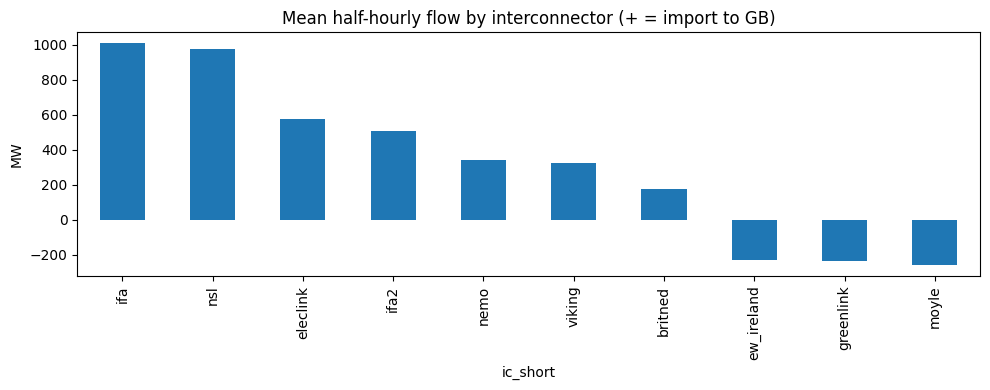

In [11]:
# Quick visual: average daily net import per interconnector
ic_avg = (
    ic.groupby('ic_short')['flow_mw']
    .mean()
    .sort_values(ascending=False)
)
ic_avg.plot(kind='bar', figsize=(10, 4), title='Mean half-hourly flow by interconnector (+ = import to GB)')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

In [12]:
# ---------------------------------------------------------------------------
# Engineer D-2 interconnector features  →  features for day D
# ---------------------------------------------------------------------------

# Per-interconnector daily mean flow
ic_pivot = (
    ic
    .groupby(['settlement_date', 'ic_short'])['flow_mw']
    .mean()
    .unstack('ic_short')  # columns = one per interconnector
    .add_prefix('ic_mean_')  # e.g. ic_mean_ifa, ic_mean_britned, ...
    .reset_index()
)

# Aggregate total net import (all interconnectors summed)
ic_total = (
    ic
    .groupby(['settlement_date', 'settlement_period'])['flow_mw']
    .sum()                   # sum across all ICs per SP
    .groupby('settlement_date')
    .agg(
        ic_total_mean='mean',  # daily mean total net import
        ic_total_min='min',    # max export hour (most negative)
        ic_total_max='max',    # peak import hour
    )
    .reset_index()
)

ic_daily = ic_pivot.merge(ic_total, on='settlement_date', how='outer')

# Rolling 7-day mean total net import
ic_daily = ic_daily.sort_values('settlement_date')
ic_daily['ic_total_roll7'] = ic_daily['ic_total_mean'].rolling(7, min_periods=1).mean()

# --- LEAKAGE SHIFT: D-2 data becomes feature for D ---
# At bid time (before 10:00 on D-1), only D-2 has a complete day of actuals.
ic_features = ic_daily.copy()
ic_features['target_date'] = ic_features['settlement_date'] + pd.Timedelta(days=2)
ic_features = ic_features.drop(columns='settlement_date')

print(ic_features.shape)
ic_features.head()

(1156, 15)


,ic_mean_britned,ic_mean_eleclink,ic_mean_ew_ireland,ic_mean_greenlink,ic_mean_ifa,ic_mean_ifa2,ic_mean_moyle,ic_mean_nemo,ic_mean_nsl,ic_mean_viking,ic_total_mean,ic_total_min,ic_total_max,ic_total_roll7,target_date
0,282.416667,993.875000,-364.916667,NaN,913.708333,968.208333,-349.500000,582.458333,320.166667,NaN,3346.416667,-402,6138,3346.416667,2023-01-03
1,881.208333,995.750000,76.708333,NaN,713.625000,766.291667,-59.958333,897.208333,1116.375000,NaN,5387.208333,2376,7228,4366.812500,2023-01-04
2,621.791667,633.000000,17.875000,NaN,449.875000,418.416667,-4.833333,561.416667,315.416667,NaN,3012.958333,-1010,6256,3915.527778,2023-01-05
3,384.250000,649.708333,10.125000,NaN,432.958333,442.791667,-80.583333,533.083333,423.125000,NaN,2795.458333,-4112,5994,3635.510417,2023-01-06
4,403.750000,452.041667,-64.041667,NaN,526.500000,121.375000,-0.208333,391.750000,403.000000,NaN,2234.166667,-2292,6106,3355.241667,2023-01-07


## 3. Merge & Validate

In [13]:
features = drm_features.merge(ic_features, on='target_date', how='inner')
features = features.sort_values('target_date').reset_index(drop=True)

print(f"Final feature table: {features.shape}")
print(f"Date range: {features['target_date'].min().date()} → {features['target_date'].max().date()}")
features.head()

Final feature table: (1156, 20)
Date range: 2023-01-03 → 2026-03-03


,drm_mean,drm_min,lolp_max,drm_eve_mean,drm_roll7,target_date,ic_mean_britned,ic_mean_eleclink,ic_mean_ew_ireland,ic_mean_greenlink,ic_mean_ifa,ic_mean_ifa2,ic_mean_moyle,ic_mean_nemo,ic_mean_nsl,ic_mean_viking,ic_total_mean,ic_total_min,ic_total_max,ic_total_roll7
0,18576.551506,9964.6984,0.000000e+00,10863.235567,18576.551506,2023-01-03,282.416667,993.875000,-364.916667,NaN,913.708333,968.208333,-349.500000,582.458333,320.166667,NaN,3346.416667,-402,6138,3346.416667
1,15738.122901,8339.1552,0.000000e+00,9039.462973,17157.337204,2023-01-04,881.208333,995.750000,76.708333,NaN,713.625000,766.291667,-59.958333,897.208333,1116.375000,NaN,5387.208333,2376,7228,4366.812500
2,18179.705035,11303.2561,0.000000e+00,11875.885667,17498.126481,2023-01-05,621.791667,633.000000,17.875000,NaN,449.875000,418.416667,-4.833333,561.416667,315.416667,NaN,3012.958333,-1010,6256,3915.527778
3,20467.905556,13910.9850,0.000000e+00,14632.559533,18240.571250,2023-01-06,384.250000,649.708333,10.125000,NaN,432.958333,442.791667,-80.583333,533.083333,423.125000,NaN,2795.458333,-4112,5994,3635.510417
4,16047.574733,9427.1663,6.000000e-08,10655.373733,17801.971946,2023-01-07,403.750000,452.041667,-64.041667,NaN,526.500000,121.375000,-0.208333,391.750000,403.000000,NaN,2234.166667,-2292,6106,3355.241667


In [14]:
# ---------------------------------------------------------------------------
# No-leakage validation
# ---------------------------------------------------------------------------
# Every feature column was derived from D-2 data.
# At bid time (before 10:00 on D-1), only D-2 actuals are fully available.
# Verify that the source date (target_date - 2) is strictly before target_date.
source_date_implied = features['target_date'] - pd.Timedelta(days=2)

assert (source_date_implied < features['target_date']).all(), "LEAKAGE DETECTED"
# Also verify the 2-day gap is maintained (not just any earlier date)
assert ((features['target_date'] - source_date_implied) == pd.Timedelta(days=2)).all(), \
    "WRONG LAG: expected exactly 2-day gap between feature source and target"
print("No-leakage check PASSED: all feature source dates are D-2 (2 days before target_date).")

No-leakage check PASSED: all feature source dates are D-2 (2 days before target_date).


In [15]:
# Missing value summary
nulls = features.isnull().sum()
nulls = nulls[nulls > 0]
if nulls.empty:
    print("No missing values.")
else:
    print("Missing values:")
    print(nulls)

Missing values:
ic_mean_greenlink    582
ic_mean_viking       324
dtype: int64


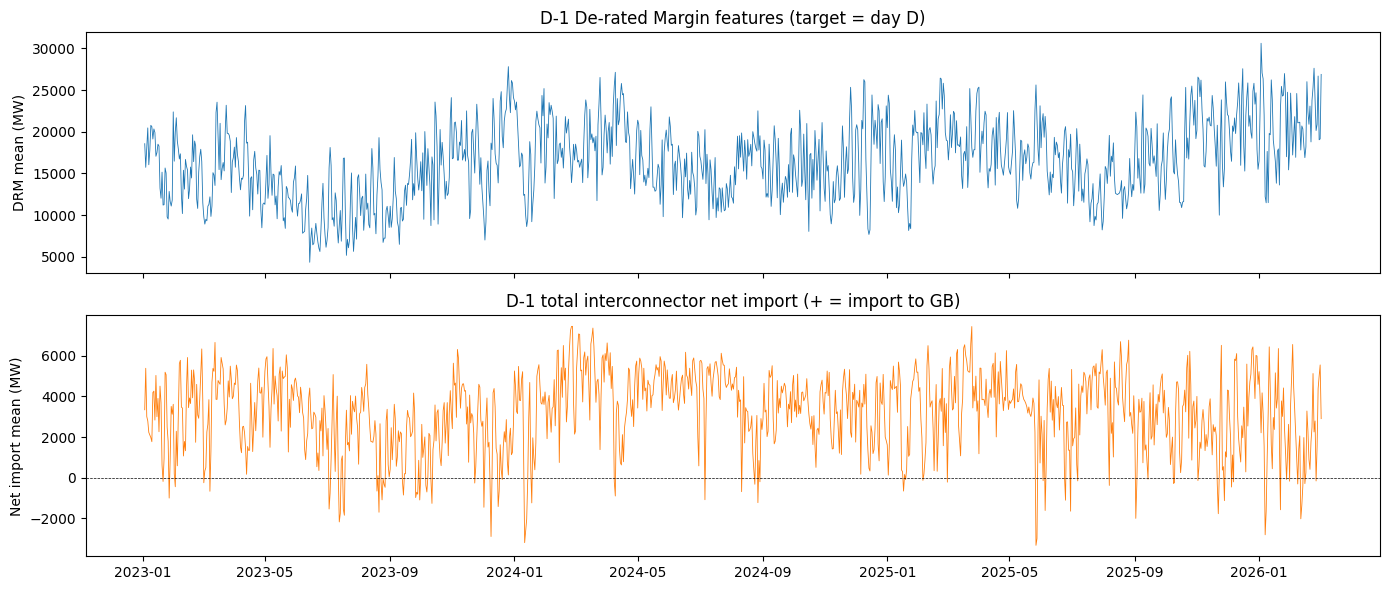

In [16]:
# Quick visual: DRM and total net import over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(features['target_date'], features['drm_mean'], linewidth=0.6)
axes[0].set_ylabel('DRM mean (MW)')
axes[0].set_title('D-1 De-rated Margin features (target = day D)')

axes[1].plot(features['target_date'], features['ic_total_mean'], linewidth=0.6, color='tab:orange')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Net import mean (MW)')
axes[1].set_title('D-1 total interconnector net import (+ = import to GB)')

plt.tight_layout()
plt.show()

## 4. Save

In [17]:
features.to_parquet(OUT_PATH, index=False)
print(f"Saved {len(features)} rows × {len(features.columns)} cols → {OUT_PATH}")
print("\nColumns:")
for col in features.columns:
    print(f"  {col}")

Saved 1156 rows × 20 cols → data/processed/features_drm_interconnectors.parquet

Columns:
  drm_mean
  drm_min
  lolp_max
  drm_eve_mean
  drm_roll7
  target_date
  ic_mean_britned
  ic_mean_eleclink
  ic_mean_ew_ireland
  ic_mean_greenlink
  ic_mean_ifa
  ic_mean_ifa2
  ic_mean_moyle
  ic_mean_nemo
  ic_mean_nsl
  ic_mean_viking
  ic_total_mean
  ic_total_min
  ic_total_max
  ic_total_roll7
